In [33]:
import os
import pandas as pd
import numpy as np
import torch

torch.set_default_dtype(torch.float32)


# Constants
path = "/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/data/carOBD/obdiidata"
sensor_cols = target_columns = [
    'ENGINE_RPM ()',                    # correlates with speed, load
    'VEHICLE_SPEED ()',                 # VSS glitch detection
    'THROTTLE ()',                      # TPS drift, throttle-load correlation
    'ENGINE_LOAD ()',                   # pair with throttle for mismatch
    'COOLANT_TEMPERATURE ()',           # intermittent sensor faults
    'INTAKE_MANIFOLD_PRESSURE ()',      # MAF/MAP drift detection
    'SHORT_TERM_FUEL_TRIM_BANK_1 ()',  # critical for air/fuel faults
    'LONG_TERM_FUEL_TRIM_BANK_1 ()',   # detects persistent issues
]

id_col = "drive_id"
time_col = 'ENGINE_RUN_TINE ()'
window_size = 300     # 300
forecast_horizon = 1

# %%
df_list = []
for file in os.listdir(path):
    if file.endswith('.csv'):
        df = pd.read_csv(f'{path}/{file}', index_col=False)
        df['drive_id'] = file
        df_list.append(df)


print(f'{len(df_list)} files loaded out of {len([f for f in os.listdir(path) if f.endswith(".csv")])}')


# %%
def remove_zero_variance_columns(df: pd.DataFrame, exclude_cols: list[str] = None) -> pd.DataFrame:
    """
    Compute std of each std-computable column (numeric only)
    """
    if exclude_cols is None:
        exclude_cols = []
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    cols_to_check = [col for col in numeric_cols if col not in exclude_cols]
  
    std_df = df[cols_to_check].std()
    zero_variance_cols = std_df[std_df == 0].index.tolist()
  
    print(f'{len(zero_variance_cols)} columns with zero variance: {zero_variance_cols}')
  
    if len(zero_variance_cols) > 0:
        df = df.drop(columns=zero_variance_cols)
  
    return df


# %%
def mean_fill_missing_timestamps_and_remove_duplicates(df: pd.DataFrame, time_col: str, id_cols: list[str] = None) -> pd.DataFrame:
    """
    Remove duplicate timestamps by averaging all numeric columns for each unique timestamp.
    This preserves the overall statistics while removing duplicate entries.
    
    Note: The time column itself is not averaged (it becomes the group key).
    Only numeric columns are averaged when multiple rows share the same timestamp.
    """
    if id_cols is None:
        id_cols = []
    
    existing_id_cols = [col for col in id_cols if col in df.columns]
    
    group_cols = [time_col] + existing_id_cols
    
    agg_dict = {}
    for col in df.columns:
        if col not in group_cols:
            if pd.api.types.is_numeric_dtype(df[col]):
                agg_dict[col] = 'mean'
            else:
                agg_dict[col] = 'first'
  
    df_clean = df.groupby(group_cols, as_index=False).agg(agg_dict)
  
    return df_clean


# %%
def downsample(df, time_col, source_file_col, downsample_factor=2):
    result_dfs = []
    
    for source_file in df[source_file_col].unique():
        file_df = df[df[source_file_col] == source_file].copy()
        
        if len(file_df) < downsample_factor * 2:
            continue
        
        file_df = file_df.sort_values(time_col).reset_index(drop=True)
        
        # Simple decimation without pre-smoothing
        downsampled = file_df.iloc[::downsample_factor].copy()
        downsampled[time_col] = np.arange(len(downsampled)) * downsample_factor
        
        result_dfs.append(downsampled.reset_index(drop=True))
    
    return pd.concat(result_dfs, ignore_index=True)


# %%
def filter_long_drives(df, id_col='drive_id', min_length=608):
    """Keep only drives long enough for your context window"""
    drive_lengths = df.groupby(id_col).size()
    valid_drives = drive_lengths[drive_lengths >= min_length].index
    
    print(f"Keeping {len(valid_drives)}/{df[id_col].nunique()} drives")
    print(f"Dropped {len(df) - df[df[id_col].isin(valid_drives)].shape[0]} timesteps")
    
    return df[df[id_col].isin(valid_drives)].reset_index(drop=True)


# %%
# Combine all dataframes
data = pd.concat(df_list, ignore_index=True)


# Clean up
print(f"Total samples: {len(data):,}")
print(f"Unique drives: {data['drive_id'].nunique()}")


# remove some useless columns
data = data.drop(columns=['WARM_UPS_SINCE_CODES_CLEARED ()', 'TIME_SINCE_TROUBLE_CODES_CLEARED ()'])


data = mean_fill_missing_timestamps_and_remove_duplicates(data, time_col=time_col, id_cols=["drive_id"])
data = remove_zero_variance_columns(data, exclude_cols=["drive_id"])
data = downsample(
    data,
    time_col=time_col,
    source_file_col='drive_id',
    downsample_factor=1
)


data = filter_long_drives(data, min_length=window_size + forecast_horizon)


# %%
def add_cross_channel_features(data):
    """
    Engineer features that capture cross-channel relationships.
    Add these as conditional columns.
    """
    # RPM-to-Speed ratio (gear indicator)
    if 'ENGINE_RPM ()' in data.columns and 'VEHICLE_SPEED ()' in data.columns:
        data['RPM_SPEED_RATIO'] = data['ENGINE_RPM ()'] / (data['VEHICLE_SPEED ()'] + 1)
    
    # Throttle-to-Load ratio (efficiency indicator)
    if 'THROTTLE ()' in data.columns and 'ENGINE_LOAD ()' in data.columns:
        data['THROTTLE_LOAD_RATIO'] = data['THROTTLE ()'] / (data['ENGINE_LOAD ()'] + 1)
    
    # Speed-based categories
    if 'VEHICLE_SPEED ()' in data.columns:
        data['IS_IDLE'] = (data['VEHICLE_SPEED ()'] < 5).astype(float)
        data['IS_HIGHWAY'] = (data['VEHICLE_SPEED ()'] > 60).astype(float)
    
    # RPM acceleration
    if 'ENGINE_RPM ()' in data.columns:
        data['RPM_ACCEL'] = data.groupby('drive_id')['ENGINE_RPM ()'].diff().fillna(0)
    
    return data


# Apply cross-channel features before preprocessing
data = add_cross_channel_features(data)
print("Added cross-channel features")


# %%
import numpy as np
import pandas as pd


# Ensure data is sorted
data = data.sort_values(["drive_id", time_col]).reset_index(drop=True)


# Get unique drive IDs
unique_drives = data['drive_id'].unique()
n_drives = len(unique_drives)


# Split drives into train/val/test groups (70/15/15)
train_drives = unique_drives[:int(0.70 * n_drives)]
val_drives   = unique_drives[int(0.70 * n_drives):int(0.85 * n_drives)]
test_drives  = unique_drives[int(0.85 * n_drives):]


print(f"Train drives: {len(train_drives)}, Val drives: {len(val_drives)}, Test drives: {len(test_drives)}")


# Create split dataframes
train_data = data[data['drive_id'].isin(train_drives)].copy()
val_data   = data[data['drive_id'].isin(val_drives)].copy()
test_data  = data[data['drive_id'].isin(test_drives)].copy()


print(f"Train shape: {train_data.shape}, Val shape: {val_data.shape}, Test shape: {test_data.shape}")

129 files loaded out of 129
Total samples: 304,299
Unique drives: 129
3 columns with zero variance: ['FUEL_AIR_COMMANDED_EQUIV_RATIO ()', 'TIME_RUN_WITH_MIL_ON ()', 'DISTANCE_TRAVELED_WITH_MIL_ON ()']
Keeping 118/129 drives
Dropped 2572 timesteps
Added cross-channel features
Train drives: 82, Val drives: 18, Test drives: 18
Train shape: (49402, 28), Val shape: (17960, 28), Test shape: (12473, 28)


In [34]:
def inject_faults_with_sensor_labels(X_windows, y_windows, sensor_cols, 
                                     fault_percentage=0.30, random_state=42):
    """
    Inject faults and return SENSOR-LEVEL labels.
    
    Returns:
    - X_faulty: (N, W, D) window data with injected faults
    - y_windows: (N, D) unchanged target values
    - sensor_labels: (N, D) binary matrix - 1 if sensor i is faulty in window j
    - window_labels: (N,) binary - 1 if any fault exists in window
    """
    np.random.seed(random_state)
    
    N, W, D = X_windows.shape
    n_fault = max(1, int(N * fault_percentage))
    
    X_faulty = X_windows.clone()
    sensor_labels = torch.zeros(N, D, dtype=torch.float32)
    window_labels = torch.zeros(N, dtype=torch.long)
    
    fault_indices = np.random.choice(N, n_fault, replace=False)
    pid_idx = {name: i for i, name in enumerate(sensor_cols)}
    
    for idx in fault_indices:
        win = X_faulty[idx].numpy()
        
        fault_type = np.random.choice([
            'vss_dropout', 'maf_scale_low', 'coolant_dropout', 
            'tps_stuck', 'rpm_speed_decouple'
        ], p=[0.35, 0.25, 0.20, 0.10, 0.10])
        
        affected_sensors = []
        
        # ===== FAULT 1: VSS DROPOUT =====
        if fault_type == 'vss_dropout' and 'VEHICLE_SPEED ()' in pid_idx:
            speed_i = pid_idx['VEHICLE_SPEED ()']
            if win[:, speed_i].mean() > 0.15:
                start = int(W * 0.30)
                end = int(W * 0.70)
                win[start:end, speed_i] = 0.0
                win[start:end, speed_i] += np.random.uniform(0, 0.02, end-start)
                affected_sensors.append(speed_i)
        
        # ===== FAULT 2: MAF SCALE LOW =====
        elif fault_type == 'maf_scale_low' and 'INTAKE_MANIFOLD_PRESSURE ()' in pid_idx:
            map_i = pid_idx['INTAKE_MANIFOLD_PRESSURE ()']
            scale_factor = np.random.uniform(0.75, 0.80)
            win[:, map_i] = win[:, map_i] * scale_factor
            affected_sensors.append(map_i)
            
            if 'SHORT_TERM_FUEL_TRIM_BANK_1 ()' in pid_idx:
                stft_i = pid_idx['SHORT_TERM_FUEL_TRIM_BANK_1 ()']
                win[:, stft_i] = np.clip(win[:, stft_i] + 0.15, 0.0, 1.0)
                affected_sensors.append(stft_i)
        
        # ===== FAULT 3: COOLANT DROPOUT =====
        elif fault_type == 'coolant_dropout' and 'COOLANT_TEMPERATURE ()' in pid_idx:
            cool_i = pid_idx['COOLANT_TEMPERATURE ()']
            if win[:, cool_i].mean() > 0.5:
                n_dropouts = np.random.randint(2, 4)
                for _ in range(n_dropouts):
                    drop_start = np.random.randint(0, W - 60)
                    drop_len = np.random.randint(30, 60)
                    win[drop_start:drop_start + drop_len, cool_i] = np.random.uniform(0.05, 0.15)
                affected_sensors.append(cool_i)
        
        # ===== FAULT 4: TPS STUCK =====
        elif fault_type == 'tps_stuck' and 'THROTTLE ()' in pid_idx:
            thr_i = pid_idx['THROTTLE ()']
            freeze_point = W // 2
            stuck_value = win[freeze_point, thr_i]
            if stuck_value > 0.15 and win[:freeze_point, thr_i].std() > 0.05:
                win[freeze_point:, thr_i] = stuck_value
                affected_sensors.append(thr_i)
        
        # ===== FAULT 5: RPM-SPEED DECOUPLE =====
        elif fault_type == 'rpm_speed_decouple':
            if 'ENGINE_RPM ()' in pid_idx and 'VEHICLE_SPEED ()' in pid_idx:
                speed_i = pid_idx['VEHICLE_SPEED ()']
                rpm_i = pid_idx['ENGINE_RPM ()']
                if win[:, speed_i].mean() > 0.20 and win[:, rpm_i].mean() > 0.30:
                    start = int(W * 0.25)
                    end = int(W * 0.75)
                    win[start:end, speed_i] = win[start:end, speed_i] * np.random.uniform(0.3, 0.5)
                    affected_sensors.append(speed_i)
        
        # Update labels if fault was applied
        if len(affected_sensors) > 0:
            X_faulty[idx] = torch.tensor(win, dtype=torch.float32)
            window_labels[idx] = 1
            for sensor_i in affected_sensors:
                sensor_labels[idx, sensor_i] = 1.0
    
    return X_faulty, y_windows, sensor_labels, window_labels


In [35]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import torch
import numpy as np

def build_clean_windows(df, sensor_cols, id_col, time_col, window_size, horizon=1, scaler=None):
    """Build windows from CLEAN data only. Returns normalized windows."""
    df = df.copy().sort_values([id_col, time_col])
    df_sensors = df[[id_col, time_col] + sensor_cols].copy()
    
    # Normalize BEFORE windowing
    if scaler is None:
        scaler = MinMaxScaler()
        df_sensors[sensor_cols] = scaler.fit_transform(df_sensors[sensor_cols])
    else:
        df_sensors[sensor_cols] = scaler.transform(df_sensors[sensor_cols])
    
    X_list, y_list = [], []
    
    for drive_id, group in df_sensors.groupby(id_col):
        values = group[sensor_cols].values
        T_, num_sensors = values.shape
        if T_ <= window_size + horizon:
            continue
        
        for t in range(T_ - window_size - horizon + 1):
            X_window = values[t : t + window_size]
            y_target = values[t + window_size + horizon - 1]
            X_list.append(X_window)
            y_list.append(y_target)
    
    X = torch.tensor(np.stack(X_list), dtype=torch.float32)
    y = torch.tensor(np.stack(y_list), dtype=torch.float32)
    return X, y, scaler


# Build CLEAN windows from train/val/test
X_train, y_train, scaler_train = build_clean_windows(
    train_data, sensor_cols, id_col, time_col, window_size, scaler=None
)

X_val, y_val, _ = build_clean_windows(
    val_data, sensor_cols, id_col, time_col, window_size, scaler=scaler_train
)

X_test_clean, y_test_clean, _ = build_clean_windows(
    test_data, sensor_cols, id_col, time_col, window_size, scaler=scaler_train
)

print(f"Clean train windows: {len(X_train)}")
print(f"Clean val windows: {len(X_val)}")
print(f"Clean test windows: {len(X_test_clean)}")

# Re-inject with sensor-level labels
print("\nInjecting faults with sensor-level labels...")

X_train_sensor, _, train_sensor_labels, train_window_labels = inject_faults_with_sensor_labels(
    X_train, y_train, sensor_cols, fault_percentage=0.15, random_state=42
)

X_val_sensor, _, val_sensor_labels, val_window_labels = inject_faults_with_sensor_labels(
    X_val, y_val, sensor_cols, fault_percentage=0.15, random_state=43
)

X_test_sensor, _, test_sensor_labels, test_window_labels = inject_faults_with_sensor_labels(
    X_test_clean, y_test_clean, sensor_cols, fault_percentage=0.30, random_state=44
)

# Statistics
train_faulty = (train_sensor_labels.sum(dim=1) > 0).sum().item()
val_faulty = (val_sensor_labels.sum(dim=1) > 0).sum().item()
test_faulty = (test_sensor_labels.sum(dim=1) > 0).sum().item()

print(f"\nTrain: {train_faulty}/{len(X_train_sensor)} faulty windows")
print(f"  Avg sensors per fault: {train_sensor_labels[train_sensor_labels.sum(dim=1) > 0].sum(dim=1).mean():.2f}")

print(f"Val:   {val_faulty}/{len(X_val_sensor)} faulty windows")
print(f"  Avg sensors per fault: {val_sensor_labels[val_sensor_labels.sum(dim=1) > 0].sum(dim=1).mean():.2f}")

print(f"Test:  {test_faulty}/{len(X_test_sensor)} faulty windows")
print(f"  Avg sensors per fault: {test_sensor_labels[test_sensor_labels.sum(dim=1) > 0].sum(dim=1).mean():.2f}")

# Create dataloaders with all 4 outputs
train_ds = TensorDataset(X_train_sensor, y_train, train_sensor_labels, train_window_labels)
val_ds = TensorDataset(X_val_sensor, y_val, val_sensor_labels, val_window_labels)
test_ds = TensorDataset(X_test_sensor, y_test_clean, test_sensor_labels, test_window_labels)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print("\n✓ Data prepared with sensor-level labels")(X_train_mixed, y_train_mixed, train_labels)
val_ds = TensorDataset(X_val_mixed, y_val_mixed, val_labels)
test_ds = TensorDataset(X_test_mixed, y_test_mixed, test_labels)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

num_sensors = len(sensor_cols)
print(f"\nTrain windows: {len(train_ds)}, Sensors: {num_sensors}")


Clean train windows: 24802
Clean val windows: 12560
Clean test windows: 7073

Train: 24802 windows (3720 faulty)
Val:   12560 windows (1884 faulty)
Test:  7073 windows (2121 faulty)

Train windows: 24802, Sensors: 8



VISUALLY IDENTIFYING INJECTED FAULTS (5 Random Examples)


▼ Example 1/5:


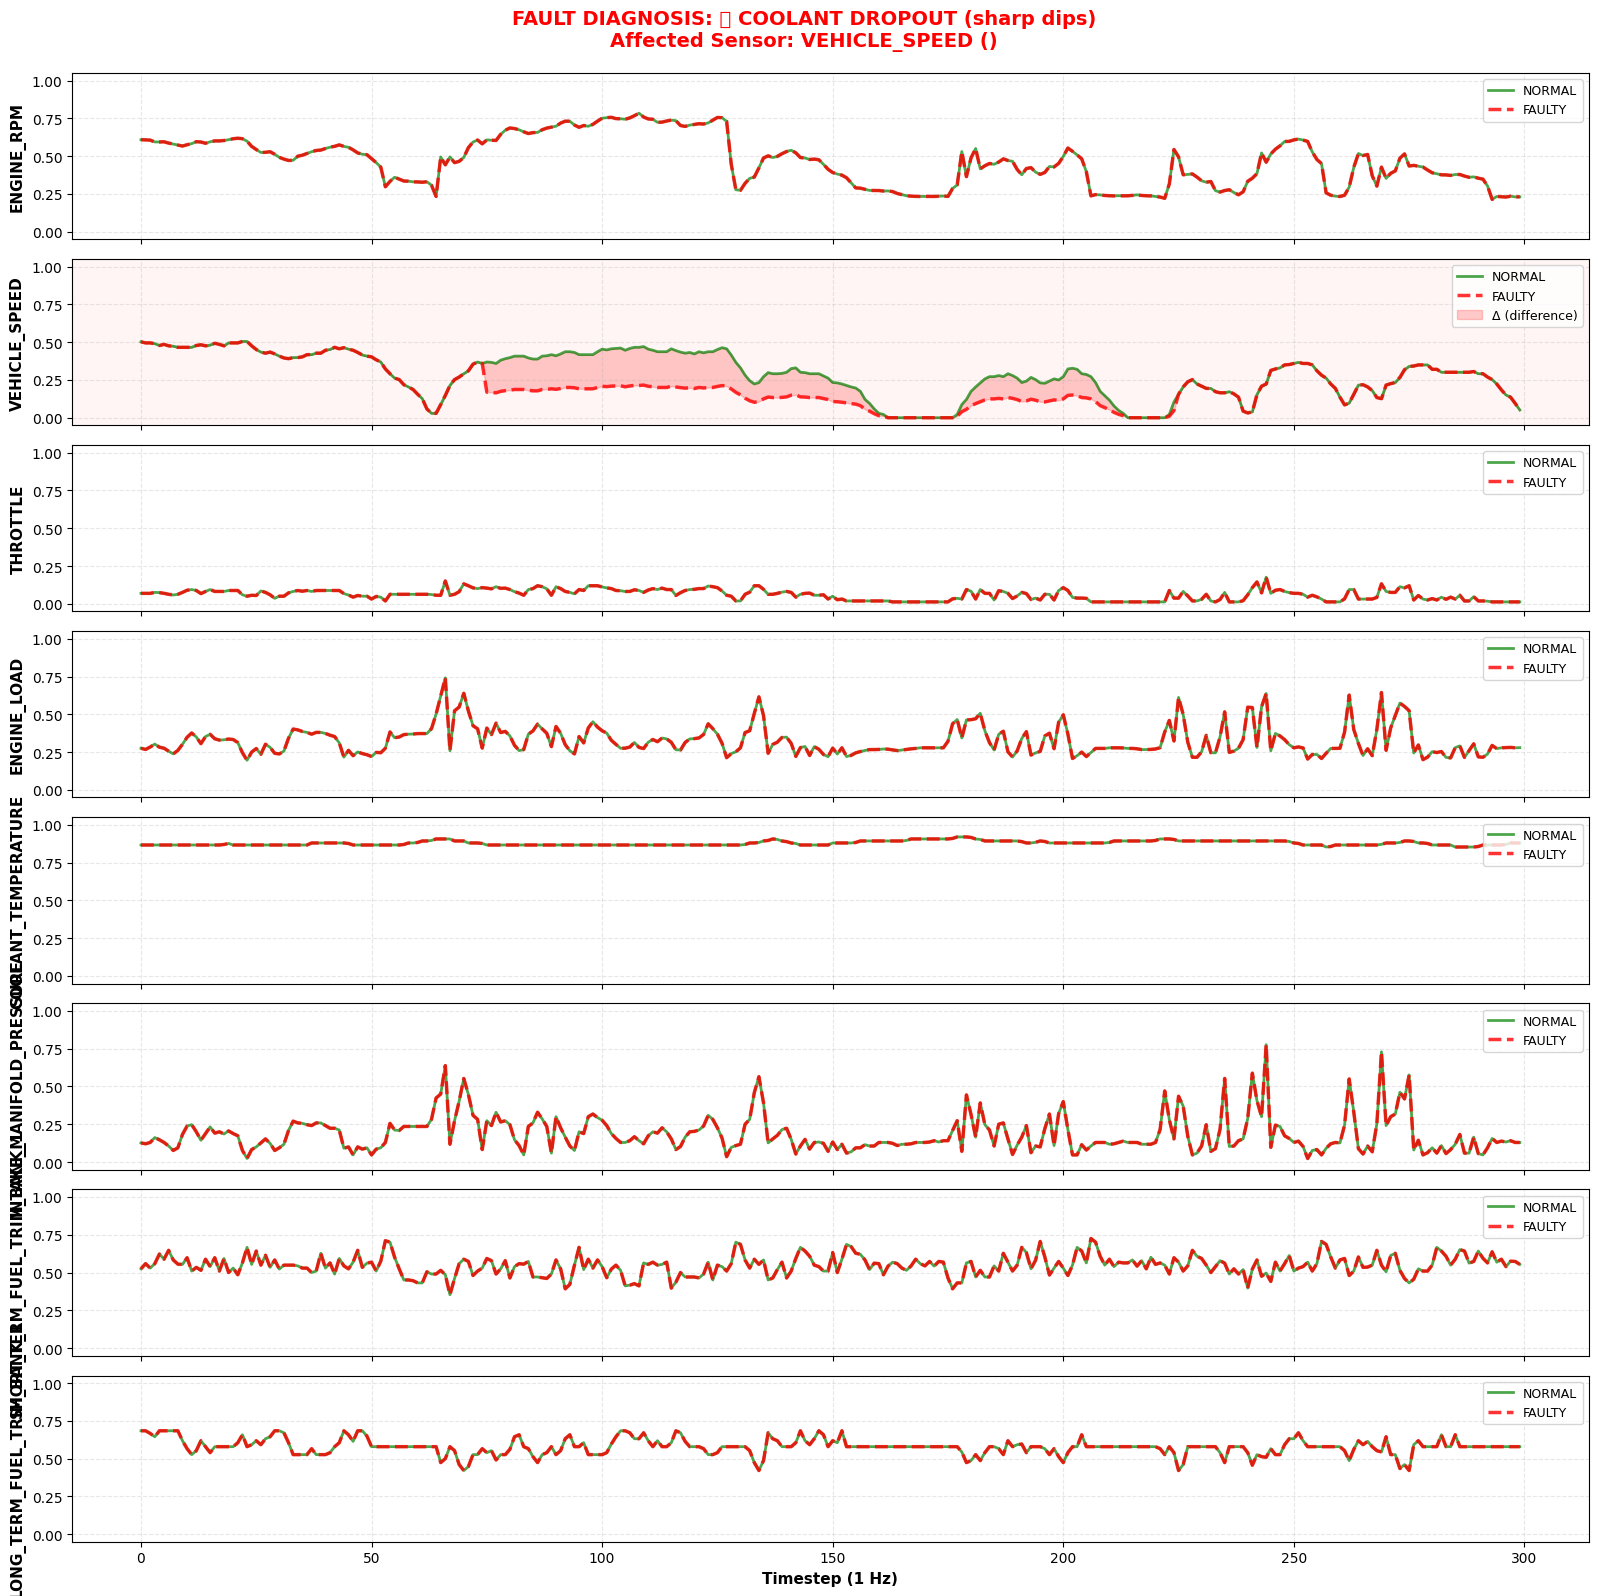


FAULT DIAGNOSIS for Window #2883
✓ Diagnosis: 🟠 COOLANT DROPOUT (sharp dips)
✓ Affected Sensor: VEHICLE_SPEED ()


▼ Example 2/5:


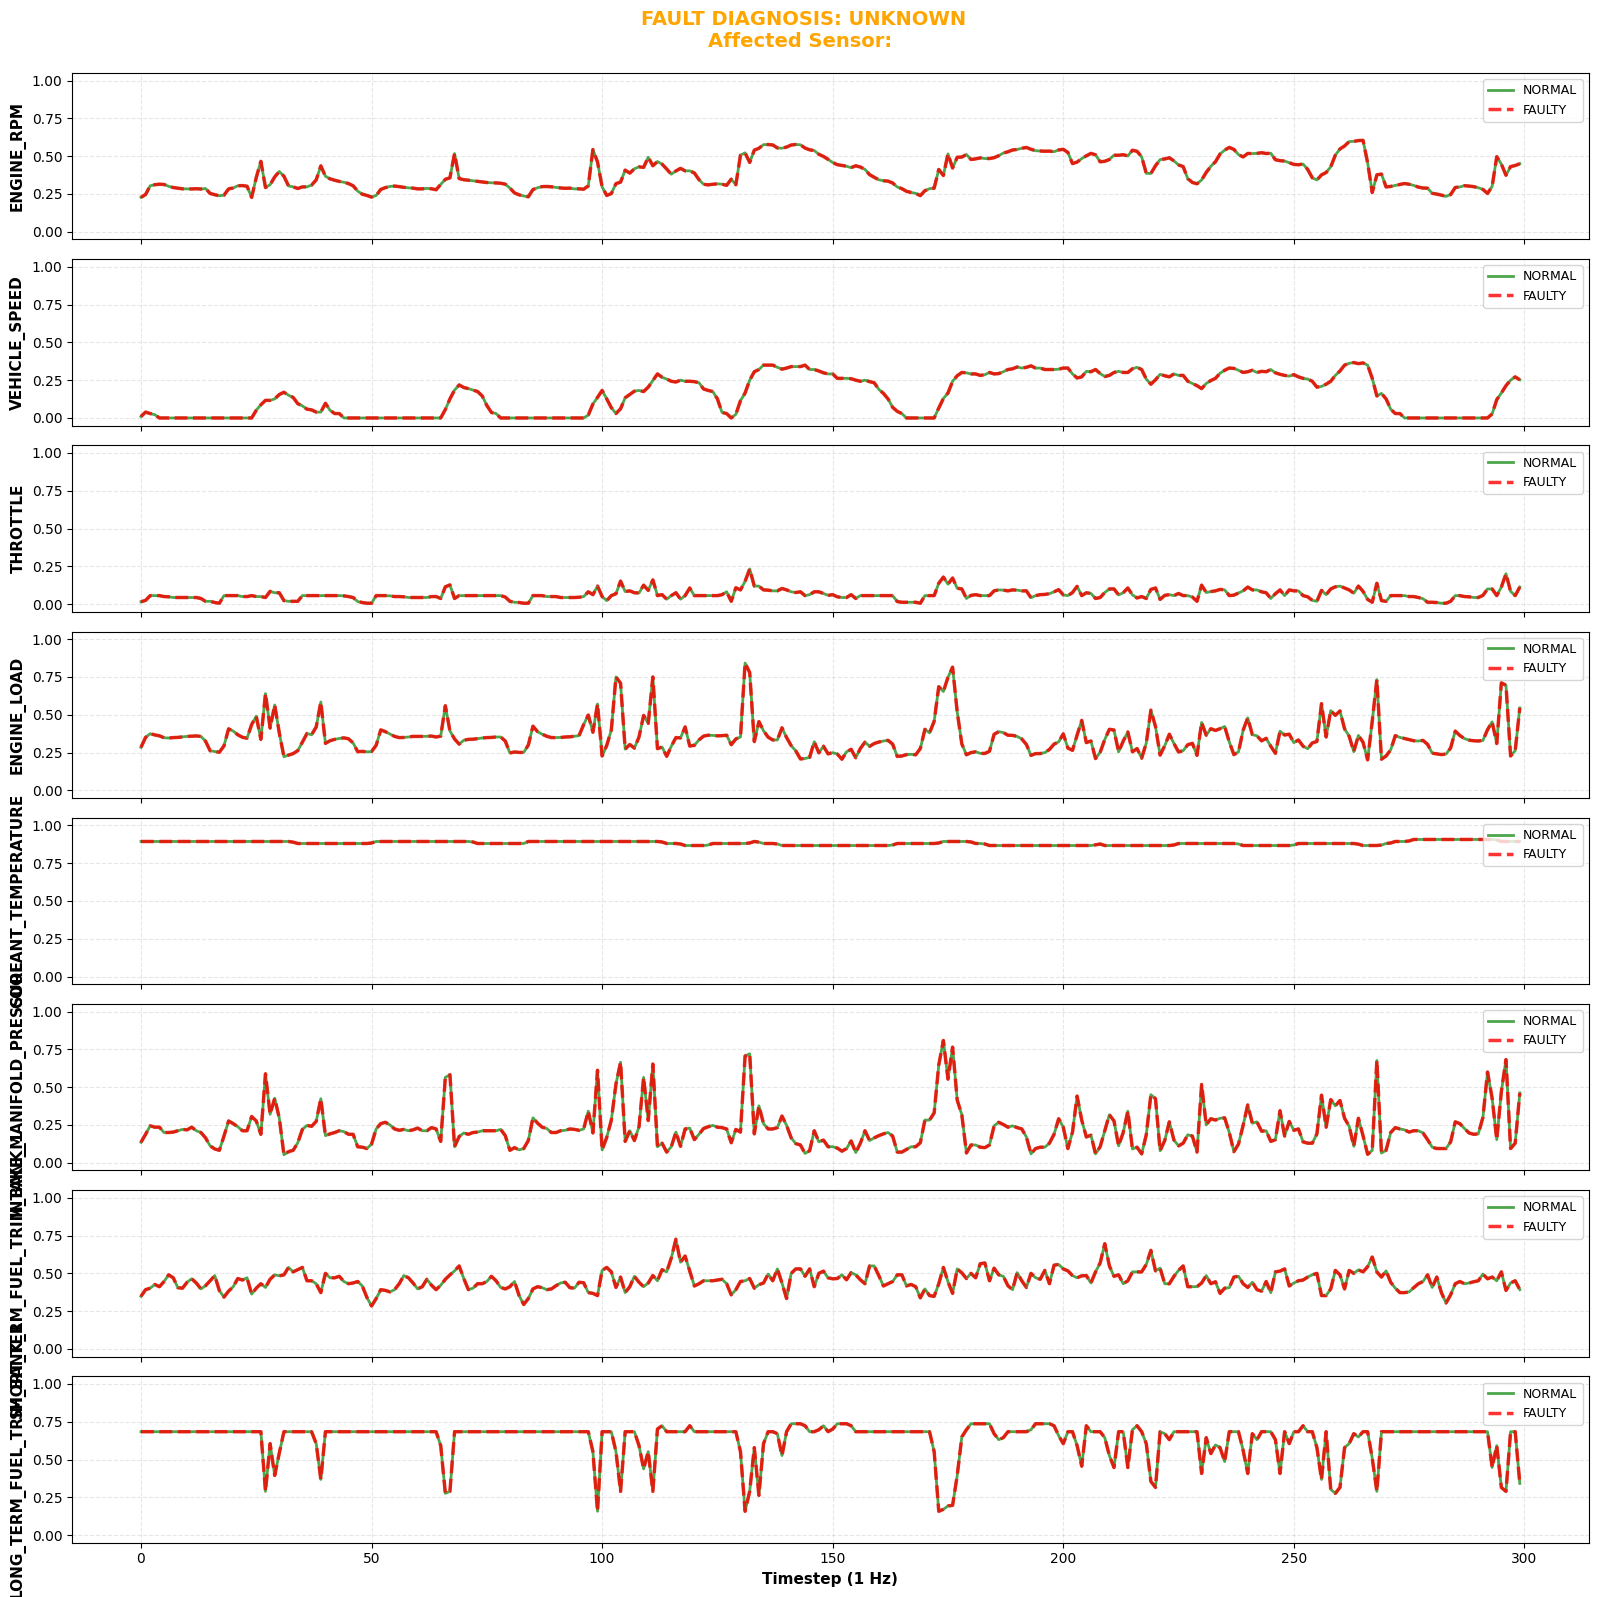


FAULT DIAGNOSIS for Window #165
✓ Diagnosis: UNKNOWN
✓ Affected Sensor: 


▼ Example 3/5:


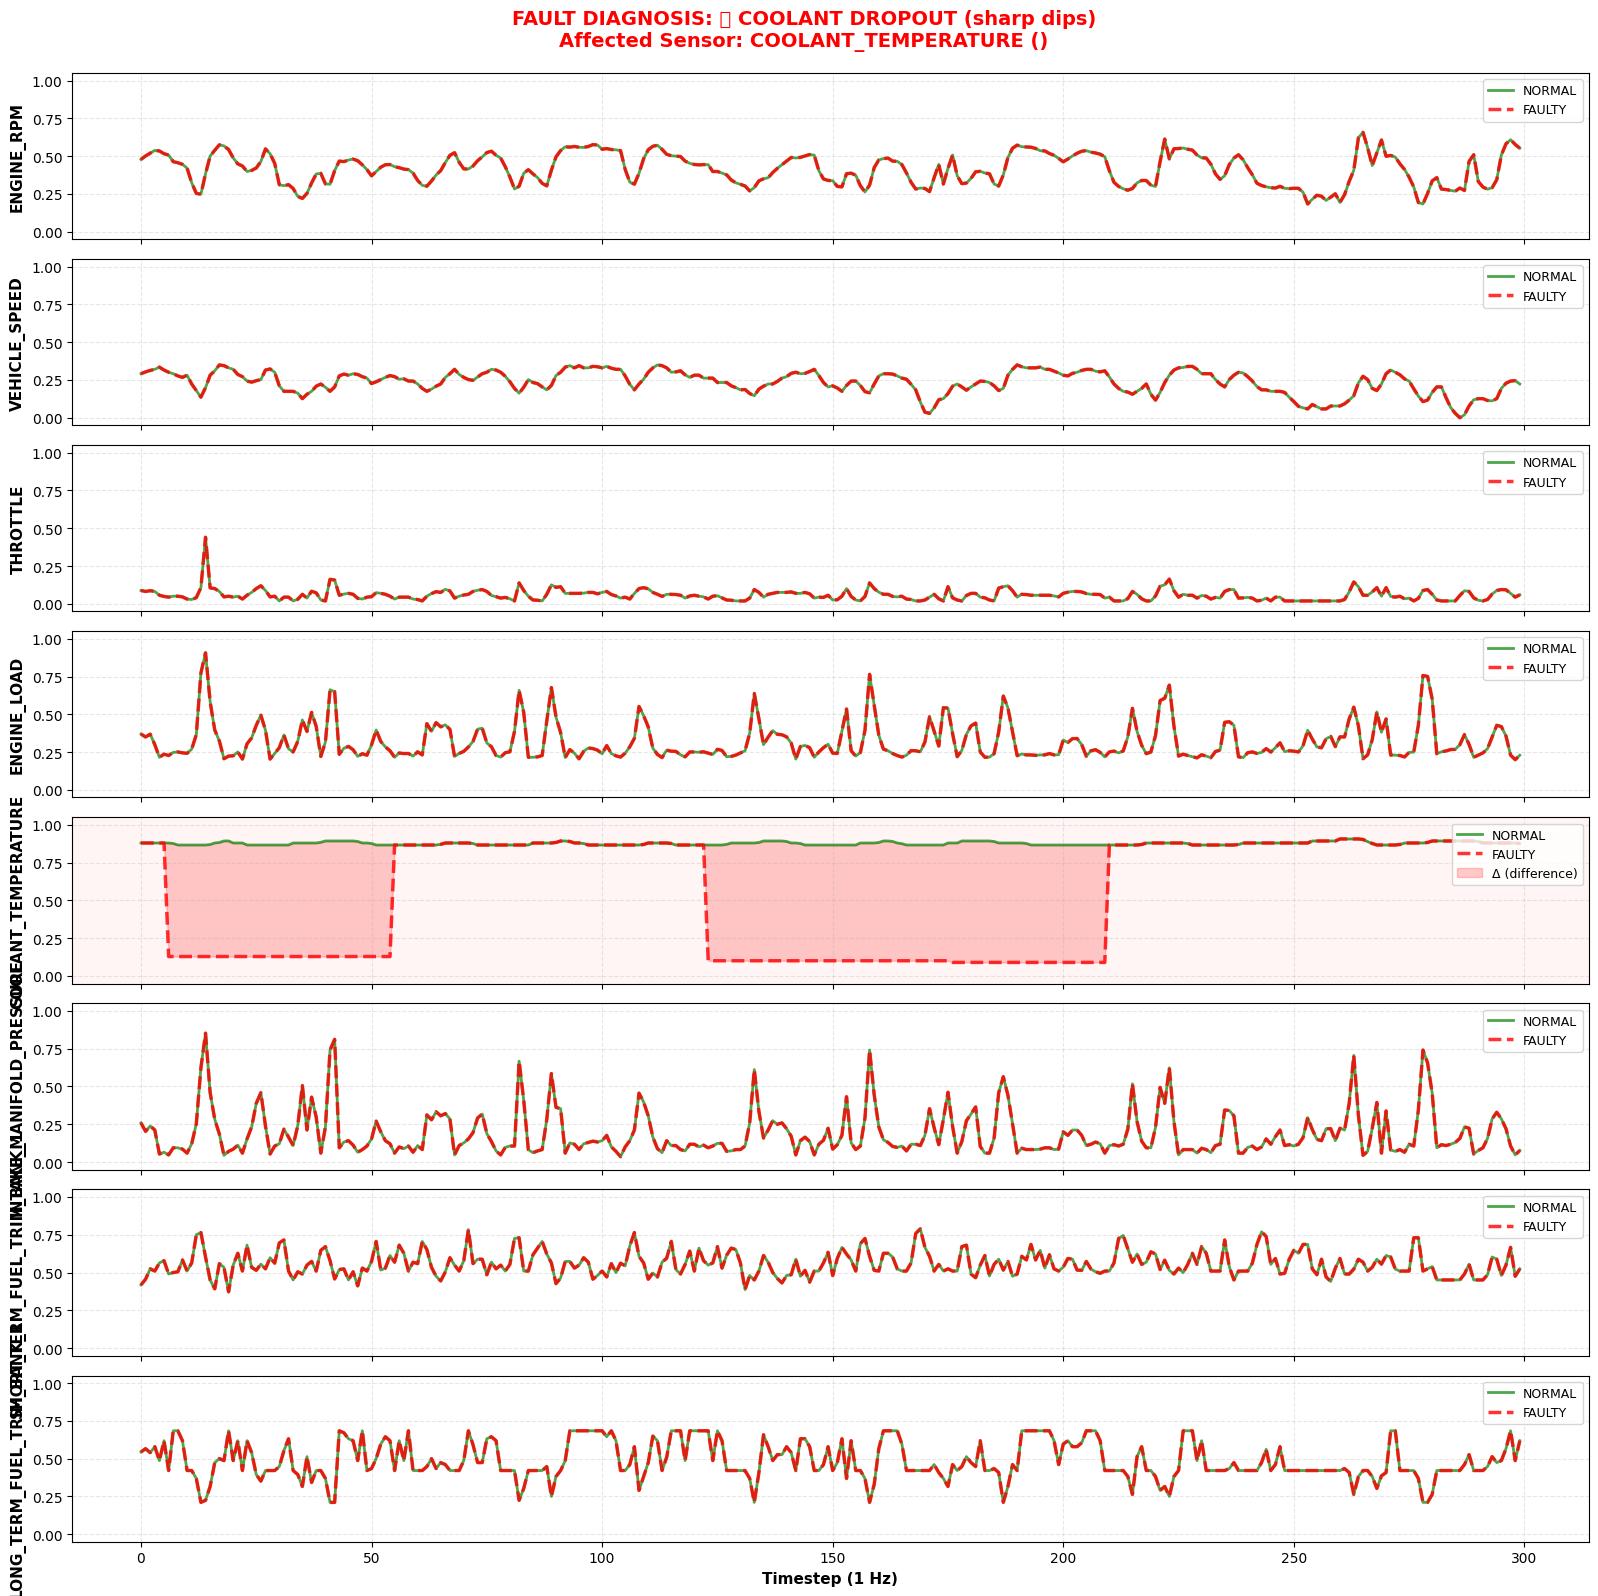


FAULT DIAGNOSIS for Window #3472
✓ Diagnosis: 🟠 COOLANT DROPOUT (sharp dips)
✓ Affected Sensor: COOLANT_TEMPERATURE ()


▼ Example 4/5:


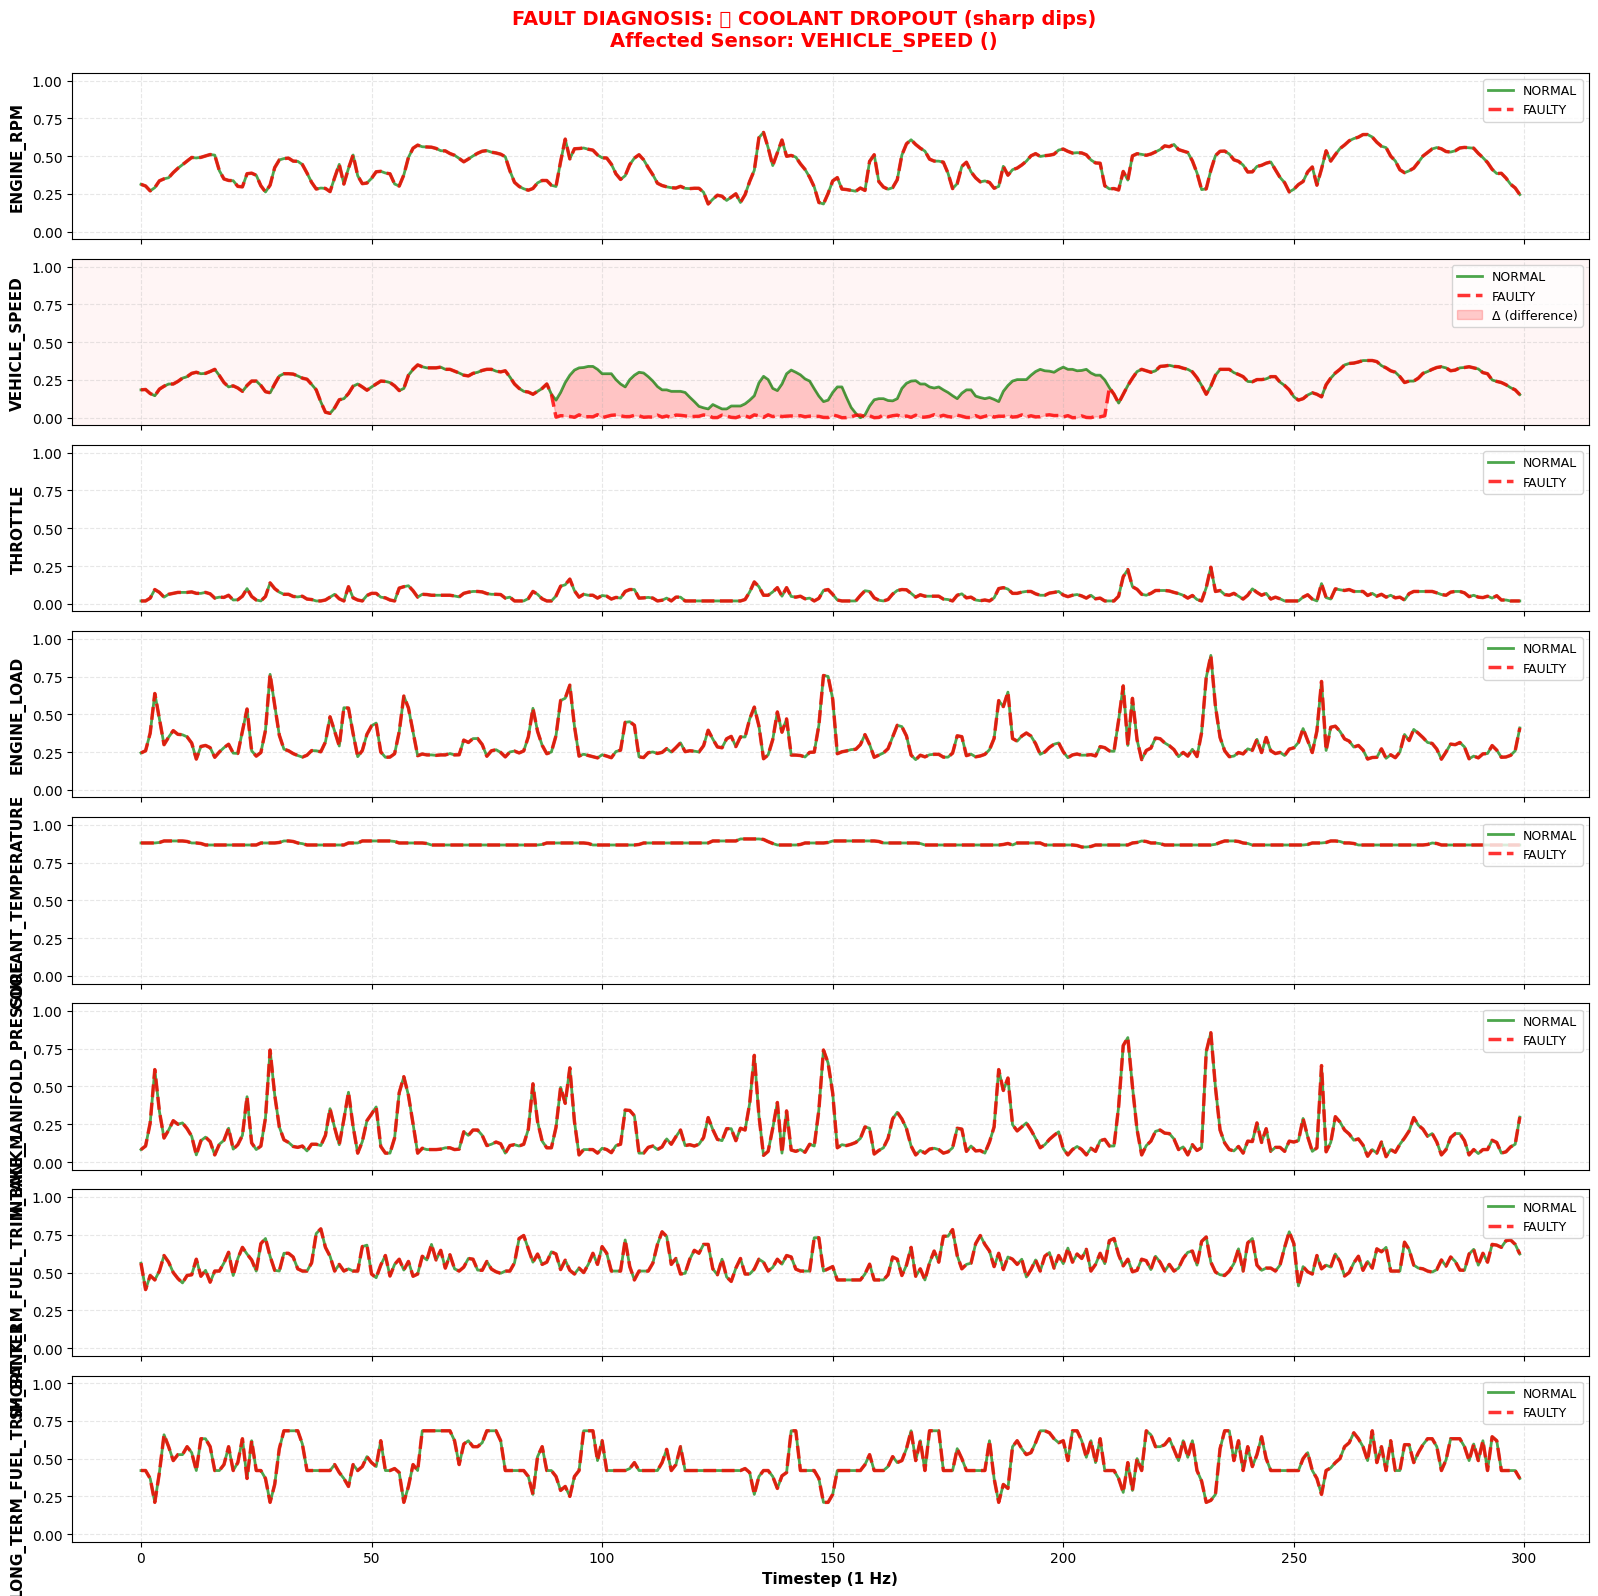


FAULT DIAGNOSIS for Window #3602
✓ Diagnosis: 🟠 COOLANT DROPOUT (sharp dips)
✓ Affected Sensor: VEHICLE_SPEED ()


▼ Example 5/5:


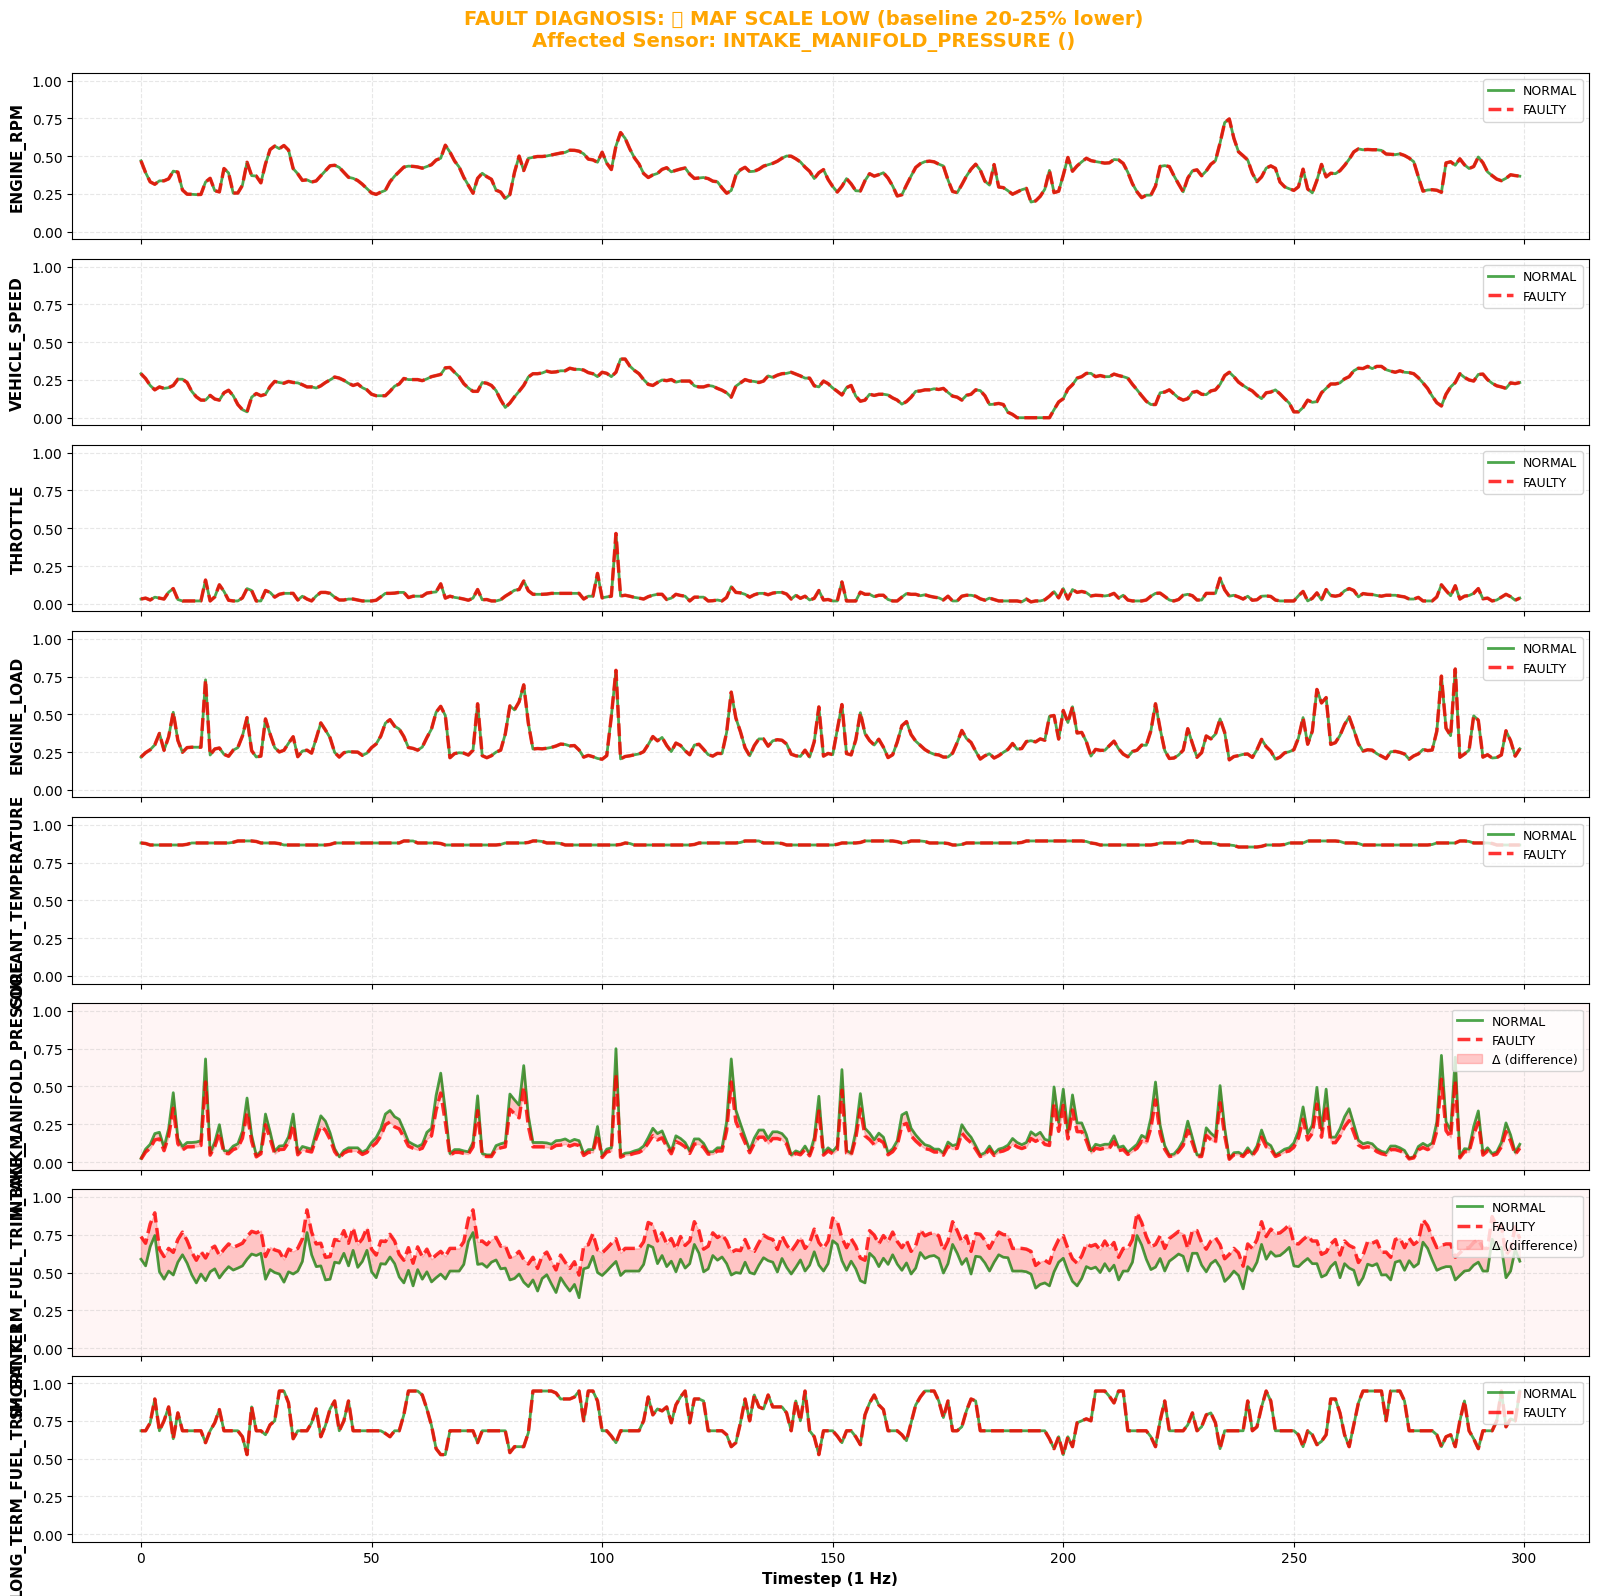


FAULT DIAGNOSIS for Window #6632
✓ Diagnosis: 🟡 MAF SCALE LOW (baseline 20-25% lower)
✓ Affected Sensor: INTAKE_MANIFOLD_PRESSURE ()



In [36]:

import matplotlib.pyplot as plt
import numpy as np

def diagnose_injected_fault(X_clean, X_faulty, labels, sensor_cols, window_idx=None):
    """
    Plot faulty windows and DIAGNOSE which fault was injected based on signal patterns.
    
    This mimics what a mechanic would do: look at the plot and identify the problem.
    """
    faulty_indices = np.where(labels.numpy() == 1)[0]
    
    if window_idx is None:
        window_idx = np.random.choice(faulty_indices)
    
    normal_window = X_clean[window_idx].numpy()
    faulty_window = X_faulty[window_idx].numpy()
    
    n_sensors = len(sensor_cols)
    timesteps = np.arange(len(normal_window))
    
    # Diagnose fault type
    pid_idx = {name: i for i, name in enumerate(sensor_cols)}
    fault_diagnosis = "UNKNOWN"
    affected_sensor = ""
    
    # Check each sensor for fault patterns
    for i, sensor_name in enumerate(sensor_cols):
        diff = np.abs(faulty_window[:, i] - normal_window[:, i])
        if diff.max() > 0.01:  # Significant change
            # Pattern 1: FLAT LINE (dropout)
            if np.std(faulty_window[50:250, i]) < 0.02 and faulty_window[50:250, i].mean() < 0.1:
                fault_diagnosis = "🔴 VSS DROPOUT (flat line at ~0)"
                affected_sensor = sensor_name
                break
            
            # Pattern 2: Entire signal shifted down
            elif diff.mean() > 0.01 and np.allclose(faulty_window[:, i], normal_window[:, i] * 0.75, atol=0.05):
                fault_diagnosis = "🟡 MAF SCALE LOW (baseline 20-25% lower)"
                affected_sensor = sensor_name
                break
            
            # Pattern 3: Multiple sharp dips
            local_minima = 0
            for j in range(10, len(faulty_window) - 10):
                if faulty_window[j, i] < 0.2 and faulty_window[j-5:j+5, i].min() < 0.15:
                    local_minima += 1
            if local_minima >= 2:
                fault_diagnosis = "🟠 COOLANT DROPOUT (sharp dips)"
                affected_sensor = sensor_name
                break
            
            # Pattern 4: Perfectly flat line in second half
            second_half_std = np.std(faulty_window[len(faulty_window)//2:, i])
            first_half_std = np.std(normal_window[:len(normal_window)//2, i])
            if second_half_std < 0.01 and first_half_std > 0.05:
                fault_diagnosis = "🟣 TPS STUCK (perfectly flat)"
                affected_sensor = sensor_name
                break
            
            # Pattern 5: Two signals decouple
            if 'ENGINE_RPM ()' in pid_idx and 'VEHICLE_SPEED ()' in pid_idx:
                if sensor_name == 'VEHICLE_SPEED ()':
                    speed_idx = i
                    rpm_idx = pid_idx['ENGINE_RPM ()']
                    speed_change = np.abs(faulty_window[:, speed_idx] - normal_window[:, speed_idx]).mean()
                    rpm_change = np.abs(faulty_window[:, rpm_idx] - normal_window[:, rpm_idx]).mean()
                    if speed_change > 0.1 and rpm_change < 0.02:
                        fault_diagnosis = "🔵 RPM-SPEED DECOUPLE (divergence)"
                        affected_sensor = "VEHICLE_SPEED + ENGINE_RPM"
                        break
    
    # Plot with diagnosis
    fig, axes = plt.subplots(n_sensors, 1, figsize=(16, 2 * n_sensors), sharex=True)
    if n_sensors == 1:
        axes = [axes]
    
    for i, sensor_name in enumerate(sensor_cols):
        # Plot both
        axes[i].plot(timesteps, normal_window[:, i], 'g-', linewidth=2, alpha=0.7, label='NORMAL')
        axes[i].plot(timesteps, faulty_window[:, i], 'r--', linewidth=2.5, alpha=0.8, label='FAULTY')
        
        diff = np.abs(faulty_window[:, i] - normal_window[:, i])
        if diff.max() > 0.01:
            axes[i].fill_between(timesteps, normal_window[:, i], faulty_window[:, i], 
                                 alpha=0.2, color='red', label='Δ (difference)')
            axes[i].set_facecolor('#fff5f5')
        
        axes[i].set_ylabel(sensor_name.split('(')[0].strip(), fontsize=11, fontweight='bold')
        axes[i].grid(True, alpha=0.3, linestyle='--')
        axes[i].set_ylim(-0.05, 1.05)
        axes[i].legend(loc='upper right', fontsize=9)
    
    axes[-1].set_xlabel("Timestep (1 Hz)", fontsize=11, fontweight='bold')
    
    title_color = 'red' if 'DROPOUT' in fault_diagnosis or 'STUCK' in fault_diagnosis else 'orange'
    fig.suptitle(
        f"FAULT DIAGNOSIS: {fault_diagnosis}\nAffected Sensor: {affected_sensor}",
        fontsize=14, fontweight='bold', color=title_color, y=0.995
    )
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*80}")
    print(f"FAULT DIAGNOSIS for Window #{window_idx}")
    print(f"{'='*80}")
    print(f"✓ Diagnosis: {fault_diagnosis}")
    print(f"✓ Affected Sensor: {affected_sensor}")
    print(f"{'='*80}\n")


# Run diagnostic on 5 random faulty windows
print("\n" + "="*80)
print("VISUALLY IDENTIFYING INJECTED FAULTS (5 Random Examples)")
print("="*80 + "\n")

for example_num in range(5):
    print(f"\n▼ Example {example_num + 1}/5:")
    diagnose_injected_fault(X_test_clean, X_test_mixed, test_labels, sensor_cols)


In [37]:
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class MultiLabelGDN(nn.Module):
    """
    Multi-Label GDN: Predicts which sensors are anomalous.
    
    Key differences from original GDN:
    1. Per-sensor anomaly classifier (not just reconstruction)
    2. Global window classifier (auxiliary task)
    3. Returns probabilities for each sensor
    """
    def __init__(self, num_nodes, window_size, embed_dim=64, top_k=3, hidden_dim=32):
        super().__init__()
        self.num_nodes = num_nodes
        self.window_size = window_size
        self.embed_dim = embed_dim
        self.top_k = min(top_k, num_nodes - 1)
        self.hidden_dim = hidden_dim
        
        # Learned sensor embeddings
        self.sensor_embeddings = nn.Parameter(torch.randn(num_nodes, embed_dim))
        nn.init.xavier_uniform_(self.sensor_embeddings)
        
        # Temporal encoder
        self.temporal_encoder = nn.GRU(
            input_size=1,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )
        
        # Graph attention
        self.gat = GATConv(hidden_dim, hidden_dim, heads=4, concat=False, 
                          dropout=0.2, add_self_loops=False)
        
        # Per-sensor anomaly classifier
        self.sensor_classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
        # Global window classifier (auxiliary)
        self.global_classifier = nn.Sequential(
            nn.Linear(num_nodes * hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    
    def build_graph_from_embeddings(self):
        """Build Top-K graph from learned embeddings."""
        emb_norm = F.normalize(self.sensor_embeddings, dim=1)
        sim_matrix = torch.mm(emb_norm, emb_norm.t())
        sim_matrix.fill_diagonal_(-1e9)
        
        topk_values, topk_indices = torch.topk(sim_matrix, self.top_k, dim=1)
        
        src_nodes = torch.arange(self.num_nodes, device=sim_matrix.device).repeat_interleave(self.top_k)
        dst_nodes = topk_indices.flatten()
        
        edge_index = torch.stack([src_nodes, dst_nodes], dim=0)
        return edge_index
    
    def forward(self, x, return_global=False):
        """
        x: (B, W, N)
        Returns: 
            - sensor_probs: (B, N) probability each sensor is anomalous
            - global_prob: (B,) probability window has any anomaly (optional)
        """
        B, W, N = x.shape
        
        # Temporal encoding per sensor
        x_flat = x.permute(0, 2, 1).reshape(B * N, W, 1)
        h_temporal, _ = self.temporal_encoder(x_flat)
        h_last = h_temporal[:, -1, :].reshape(B, N, -1)  # (B, N, hidden_dim)
        
        # Graph attention
        edge_index = self.build_graph_from_embeddings()
        
        h_graph_list = []
        for i in range(B):
            h_gat = self.gat(h_last[i], edge_index)
            h_graph_list.append(h_gat)
        
        h_graph = torch.stack(h_graph_list, dim=0)  # (B, N, hidden_dim)
        
        # Per-sensor anomaly probability
        sensor_probs = self.sensor_classifier(h_graph).squeeze(-1)  # (B, N)
        
        if return_global:
            # Global window anomaly probability
            h_flat = h_graph.flatten(1)  # (B, N * hidden_dim)
            global_prob = self.global_classifier(h_flat).squeeze(-1)  # (B,)
            return sensor_probs, global_prob
        
        return sensor_probs


def train_multilabel_with_hardmining(train_loader, val_loader, num_sensors, window_size,
                                     num_epochs=30, device='cpu', 
                                     use_hard_mining=True, mining_start_epoch=5):
    """
    Train Multi-Label GDN with optional hard negative mining.
    
    Hard mining focuses on:
    - Normal sensors with HIGH anomaly scores (false positives)
    - Faulty sensors with LOW anomaly scores (false negatives)
    """
    model = MultiLabelGDN(num_nodes=num_sensors, window_size=window_size,
                          embed_dim=32, top_k=3, hidden_dim=32).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sensor_criterion = nn.BCELoss(reduction='none')  # Per-sample loss for weighting
    global_criterion = nn.BCELoss()
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5, verbose=True
    )
    
    best_val_loss = float('inf')
    lambda_global = 0.3
    
    for epoch in range(num_epochs):
        model.train()
        train_loss_sensor = 0.0
        train_loss_global = 0.0
        
        # HARD MINING: First pass to identify hard samples (after warmup)
        if use_hard_mining and epoch >= mining_start_epoch:
            print(f"  [Hard Mining Active]")
            
            # Collect predictions for all training samples
            all_sensor_probs = []
            all_sensor_labels = []
            
            model.eval()
            with torch.no_grad():
                for X_batch, _, sensor_labels_batch, _ in train_loader:
                    X_batch = X_batch.to(device)
                    sensor_probs = model(X_batch, return_global=False)
                    all_sensor_probs.append(sensor_probs.cpu())
                    all_sensor_labels.append(sensor_labels_batch)
            
            all_sensor_probs = torch.cat(all_sensor_probs, dim=0)  # (N_train, D)
            all_sensor_labels = torch.cat(all_sensor_labels, dim=0)  # (N_train, D)
            
            # Identify hard samples per sensor
            hard_weights = torch.ones_like(all_sensor_labels)
            
            for sensor_i in range(num_sensors):
                # Hard negatives: normal sensors predicted as anomalous
                normal_mask = (all_sensor_labels[:, sensor_i] == 0)
                if normal_mask.sum() > 0:
                    normal_scores = all_sensor_probs[normal_mask, sensor_i]
                    hard_neg_threshold = normal_scores.quantile(0.75)  # Top 25%
                    hard_neg_mask = normal_mask & (all_sensor_probs[:, sensor_i] > hard_neg_threshold)
                    hard_weights[hard_neg_mask, sensor_i] = 2.0
                
                # Hard positives: faulty sensors predicted as normal
                faulty_mask = (all_sensor_labels[:, sensor_i] == 1)
                if faulty_mask.sum() > 0:
                    faulty_scores = all_sensor_probs[faulty_mask, sensor_i]
                    hard_pos_threshold = faulty_scores.quantile(0.25)  # Bottom 25%
                    hard_pos_mask = faulty_mask & (all_sensor_probs[:, sensor_i] < hard_pos_threshold)
                    hard_weights[hard_pos_mask, sensor_i] = 2.0
            
            # Convert to list for dataloader iteration
            hard_weights_list = list(hard_weights)
            sample_idx = 0
        else:
            hard_weights_list = None
        
        # Training pass
        model.train()
        for batch_idx, (X_batch, _, sensor_labels_batch, window_labels_batch) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
            X_batch = X_batch.to(device)
            sensor_labels_batch = sensor_labels_batch.to(device)
            window_labels_batch = window_labels_batch.float().to(device)
            
            optimizer.zero_grad()
            
            # Forward
            sensor_probs, global_prob = model(X_batch, return_global=True)
            
            # Sensor-level loss with optional hard mining weights
            loss_sensor_per_sample = sensor_criterion(sensor_probs, sensor_labels_batch)  # (B, N)
            
            if hard_weights_list is not None and epoch >= mining_start_epoch:
                # Apply hard mining weights
                batch_size = X_batch.size(0)
                batch_weights = torch.stack(hard_weights_list[sample_idx:sample_idx + batch_size]).to(device)
                loss_sensor = (loss_sensor_per_sample * batch_weights).mean()
                sample_idx += batch_size
            else:
                loss_sensor = loss_sensor_per_sample.mean()
            
            # Global window loss
            loss_global = global_criterion(global_prob, window_labels_batch)
            
            # Combined loss
            loss = loss_sensor + lambda_global * loss_global
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            train_loss_sensor += loss_sensor.item() * X_batch.size(0)
            train_loss_global += loss_global.item() * X_batch.size(0)
        
        train_loss_sensor /= len(train_loader.dataset)
        train_loss_global /= len(train_loader.dataset)
        
        # Validate
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, _, sensor_labels_batch, window_labels_batch in val_loader:
                X_batch = X_batch.to(device)
                sensor_labels_batch = sensor_labels_batch.to(device)
                window_labels_batch = window_labels_batch.float().to(device)
                
                sensor_probs, global_prob = model(X_batch, return_global=True)
                
                loss_sensor = sensor_criterion(sensor_probs, sensor_labels_batch).mean()
                loss_global = global_criterion(global_prob, window_labels_batch)
                loss = loss_sensor + lambda_global * loss_global
                
                val_loss += loss.item() * X_batch.size(0)
        
        val_loss /= len(val_loader.dataset)
        scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Sensor: {train_loss_sensor:.4f} | "
              f"Global: {train_loss_global:.4f} | "
              f"Val: {val_loss:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_multilabel_gdn.pt")
            print("  ✓ Best model saved")
    
    model.load_state_dict(torch.load("best_multilabel_gdn.pt"))
    return model

class ContrastiveLoss(nn.Module):
    """Supervised contrastive loss (vectorized)."""
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature
    
    def forward(self, embeddings, labels):
        """
        embeddings: (B, D) normalized
        labels: (B,) binary
        """
        device = embeddings.device
        B = embeddings.size(0)
        
        # Compute similarity matrix
        sim_matrix = torch.mm(embeddings, embeddings.t()) / self.temperature
        
        # Create masks
        labels = labels.unsqueeze(1)
        mask_pos = (labels == labels.t()).float()
        mask_pos.fill_diagonal_(0)  # Remove self-similarity
        
        mask_neg = (labels != labels.t()).float()
        
        # Numerator: sum of positive similarities
        exp_sim = torch.exp(sim_matrix)
        pos_sim = (exp_sim * mask_pos).sum(dim=1)  # (B,)
        
        # Denominator: sum of all non-self similarities
        all_sim = exp_sim.sum(dim=1) - torch.exp(torch.diagonal(sim_matrix))  # (B,)
        
        # Loss: -log(pos / all) for samples with positives
        has_pos = (mask_pos.sum(dim=1) > 0)  # Samples with at least one positive
        
        if has_pos.sum() == 0:
            # No positive pairs (all same class or all different)
            return torch.tensor(0.0, device=device, requires_grad=True)
        
        loss = -torch.log(pos_sim[has_pos] / (all_sim[has_pos] + 1e-8))
        
        return loss.mean()


def train(train_loader, val_loader, num_sensors, window_size, 
                        num_epochs=30, device='cpu'):
    """
    Train with DUAL objective: contrastive + reconstruction.
    """
    model = GDN(num_nodes=num_sensors, window_size=window_size,
                embed_dim=32, top_k=3, hidden_dim=32).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-3)
    contrastive_criterion = ContrastiveLoss(temperature=0.1)
    recon_criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5, verbose=True, threshold=1e-4
    )
    
    best_val_loss = float('inf')
    patience_counter = 0
    lambda_recon = 0.3  # Weight for reconstruction (auxiliary)
    
    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss_contrast = 0.0
        train_loss_recon = 0.0
        
        for X_batch, _, labels_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            X_batch = X_batch.to(device)
            labels_batch = labels_batch.to(device)
            
            optimizer.zero_grad()
            
            # Get both outputs
            z = model(X_batch, return_embedding=True)  # Contrastive
            recon = model(X_batch, return_embedding=False)  # Reconstruction
            
            # Dual loss
            loss_contrast = contrastive_criterion(z, labels_batch)
            loss_recon = recon_criterion(recon, X_batch[:, -1, :])
            
            loss = loss_contrast + lambda_recon * loss_recon
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            
            train_loss_contrast += loss_contrast.item() * X_batch.size(0)
            train_loss_recon += loss_recon.item() * X_batch.size(0)
        
        train_loss_contrast /= len(train_loader.dataset)
        train_loss_recon /= len(train_loader.dataset)
        
        # Validate
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, _, labels_batch in val_loader:
                X_batch, labels_batch = X_batch.to(device), labels_batch.to(device)
                z = model(X_batch, return_embedding=True)
                recon = model(X_batch, return_embedding=False)
                
                loss_contrast = contrastive_criterion(z, labels_batch)
                loss_recon = recon_criterion(recon, X_batch[:, -1, :])
                loss = loss_contrast + lambda_recon * loss_recon
                
                val_loss += loss.item() * X_batch.size(0)
        
        val_loss /= len(val_loader.dataset)
        scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs} | Contrast: {train_loss_contrast:.4f} | "
              f"Recon: {train_loss_recon:.4f} | Val: {val_loss:.4f}")
        
        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_contrastive_gdn.pt")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 10:
                print("Early stopping triggered")
                break
    
    model.load_state_dict(torch.load("best_contrastive_gdn.pt"))
    return model

def evaluate(model, test_loader, train_loader, device='cpu'):
    """
    Anomaly score = distance to normal cluster centroid in embedding space.
    """
    model.eval()
    
    # Step 1: Compute normal centroid from training data
    normal_embeddings = []
    with torch.no_grad():
        for X_batch, _, labels_batch in tqdm(train_loader, desc="Computing centroid"):
            X_batch = X_batch.to(device)
            labels_batch = labels_batch.to(device)
            
            z = model(X_batch, return_embedding=True)
            normal_mask = (labels_batch == 0)
            if normal_mask.sum() > 0:
                normal_embeddings.append(z[normal_mask].cpu())
    
    normal_embeddings = torch.cat(normal_embeddings, dim=0)
    normal_centroid = normal_embeddings.mean(dim=0).to(device)
    
    print(f"Normal centroid computed from {len(normal_embeddings)} samples")
    
    # Step 2: Compute distance to centroid for test samples
    all_scores = []
    with torch.no_grad():
        for X_batch, _, _ in tqdm(test_loader, desc="Evaluating"):
            X_batch = X_batch.to(device)
            z = model(X_batch, return_embedding=True)
            
            # Euclidean distance to normal centroid
            distances = torch.norm(z - normal_centroid.unsqueeze(0), dim=1)
            all_scores.append(distances.cpu())
    
    return torch.cat(all_scores, dim=0).numpy()



In [38]:
# %%
# TRAIN
print("\n" + "="*80)
print("Training Multi-Label GDN with Hard Negative Mining")
print("="*80 + "\n")

device = "cuda" if torch.cuda.is_available() else "cpu"

model_multilabel = train_multilabel_with_hardmining(
    train_loader, val_loader,
    num_sensors=num_sensors,
    window_size=window_size,
    num_epochs=30,
    device=device,
    use_hard_mining=True,
    mining_start_epoch=5  # Start hard mining after 5 warmup epochs
)

print("\n✓ Model saved to: best_multilabel_gdn.pt")



Training CONTRASTIVE GDN...



Epoch 1/30:   0%|          | 0/776 [00:00<?, ?it/s]

Epoch 1/30 | Contrast: 0.3323 | Recon: 0.0733 | Val: 0.2402


Epoch 2/30:   0%|          | 0/776 [00:00<?, ?it/s]

Epoch 2/30 | Contrast: 0.2956 | Recon: 0.0615 | Val: 0.2879


...

Epoch 14/30 | Contrast: 0.2592 | Recon: 0.0581 | Val: 0.2318


Epoch 15/30:   0%|          | 0/776 [00:00<?, ?it/s]

Epoch 15/30 | Contrast: 0.2621 | Recon: 0.0580 | Val: 0.2246


Epoch 16/30:   0%|          | 0/776 [00:00<?, ?it/s]

Epoch 16/30 | Contrast: 0.2665 | Recon: 0.0582 | Val: 0.2144
Early stopping triggered

✓ Model saved to: best_contrastive_gdn.pt


In [39]:
# %%
# COMPREHENSIVE EVALUATION with Per-Sensor Classification Report

from sklearn.metrics import (roc_auc_score, precision_recall_fscore_support, 
                            classification_report, confusion_matrix)
import pandas as pd

def evaluate_multilabel_comprehensive(model, test_loader, sensor_cols, device='cpu', threshold=0.5):
    """
    Comprehensive evaluation with:
    1. Per-sensor AUC, Precision, Recall, F1
    2. Classification report
    3. Window-level metrics
    4. Confusion matrices
    """
    model.eval()
    
    all_sensor_probs = []
    all_sensor_labels = []
    all_window_labels = []
    all_global_probs = []
    
    with torch.no_grad():
        for X_batch, _, sensor_labels_batch, window_labels_batch in tqdm(test_loader, desc="Evaluating"):
            X_batch = X_batch.to(device)
            sensor_probs, global_prob = model(X_batch, return_global=True)
            
            all_sensor_probs.append(sensor_probs.cpu())
            all_sensor_labels.append(sensor_labels_batch)
            all_window_labels.append(window_labels_batch)
            all_global_probs.append(global_prob.cpu())
    
    all_sensor_probs = torch.cat(all_sensor_probs, dim=0).numpy()  # (N, D)
    all_sensor_labels = torch.cat(all_sensor_labels, dim=0).numpy()  # (N, D)
    all_window_labels = torch.cat(all_window_labels, dim=0).numpy()  # (N,)
    all_global_probs = torch.cat(all_global_probs, dim=0).numpy()  # (N,)
    
    # ============ PER-SENSOR METRICS ============
    print("\n" + "="*80)
    print("PER-SENSOR ANOMALY DETECTION PERFORMANCE")
    print("="*80 + "\n")
    
    sensor_metrics = []
    
    for i, sensor_name in enumerate(sensor_cols):
        n_positive = all_sensor_labels[:, i].sum()
        
        if n_positive > 0:
            # AUC
            auc = roc_auc_score(all_sensor_labels[:, i], all_sensor_probs[:, i])
            
            # Threshold predictions
            preds = (all_sensor_probs[:, i] > threshold).astype(int)
            
            # Precision, Recall, F1
            precision, recall, f1, support = precision_recall_fscore_support(
                all_sensor_labels[:, i], preds, average='binary', zero_division=0
            )
            
            sensor_metrics.append({
                'Sensor': sensor_name.replace(' ()', ''),
                'Faults': int(n_positive),
                'AUC': auc,
                'Precision': precision,
                'Recall': recall,
                'F1': f1
            })
            
            print(f"{sensor_name:40s} | "
                  f"Faults: {int(n_positive):4d} | "
                  f"AUC: {auc:.3f} | "
                  f"P: {precision:.3f} | "
                  f"R: {recall:.3f} | "
                  f"F1: {f1:.3f}")
        else:
            print(f"{sensor_name:40s} | No faults injected")
    
    # Convert to DataFrame for easy viewing
    sensor_df = pd.DataFrame(sensor_metrics)
    
    # ============ CLASSIFICATION REPORT ============
    print("\n" + "="*80)
    print("DETAILED CLASSIFICATION REPORT (All Sensors Combined)")
    print("="*80 + "\n")
    
    # Flatten for overall report
    all_labels_flat = all_sensor_labels.flatten()
    all_preds_flat = (all_sensor_probs > threshold).astype(int).flatten()
    
    print(classification_report(all_labels_flat, all_preds_flat, 
                               target_names=['Normal', 'Anomalous'],
                               digits=3))
    
    # ============ CONFUSION MATRIX ============
    print("\n" + "="*80)
    print("CONFUSION MATRIX (All Sensors Combined)")
    print("="*80 + "\n")
    
    cm = confusion_matrix(all_labels_flat, all_preds_flat)
    print(f"                  Predicted Normal  Predicted Anomalous")
    print(f"Actually Normal        {cm[0, 0]:8d}         {cm[0, 1]:8d}")
    print(f"Actually Anomalous     {cm[1, 0]:8d}         {cm[1, 1]:8d}")
    
    # ============ WINDOW-LEVEL METRICS ============
    print("\n" + "="*80)
    print("WINDOW-LEVEL ANOMALY DETECTION")
    print("="*80 + "\n")
    
    # Method 1: Max sensor probability
    window_scores_max = all_sensor_probs.max(axis=1)
    window_auc_max = roc_auc_score(all_window_labels, window_scores_max)
    
    # Method 2: Global classifier
    window_auc_global = roc_auc_score(all_window_labels, all_global_probs)
    
    # Method 3: Average anomalous sensors
    window_scores_avg = all_sensor_probs.mean(axis=1)
    window_auc_avg = roc_auc_score(all_window_labels, window_scores_avg)
    
    print(f"Window-Level AUC (max sensor prob):    {window_auc_max:.4f}")
    print(f"Window-Level AUC (global classifier):  {window_auc_global:.4f}")
    print(f"Window-Level AUC (avg sensor prob):    {window_auc_avg:.4f}")
    
    # Best window-level predictions
    best_window_scores = window_scores_max
    window_preds = (best_window_scores > threshold).astype(int)
    
    window_precision, window_recall, window_f1, _ = precision_recall_fscore_support(
        all_window_labels, window_preds, average='binary', zero_division=0
    )
    
    print(f"\nWindow-Level (using max sensor):")
    print(f"  Precision: {window_precision:.3f}")
    print(f"  Recall:    {window_recall:.3f}")
    print(f"  F1:        {window_f1:.3f}")
    
    # ============ SUMMARY TABLE ============
    print("\n" + "="*80)
    print("SUMMARY: Top 5 Sensors by Detection Performance")
    print("="*80 + "\n")
    
    if len(sensor_df) > 0:
        top_sensors = sensor_df.nlargest(5, 'F1')
        print(top_sensors.to_string(index=False))
    
    print("\n" + "="*80 + "\n")
    
    return {
        'sensor_probs': all_sensor_probs,
        'sensor_labels': all_sensor_labels,
        'sensor_metrics': sensor_df,
        'window_auc_max': window_auc_max,
        'window_auc_global': window_auc_global,
        'confusion_matrix': cm
    }


# %%
# RUN EVALUATION
print("\n" + "="*80)
print("COMPREHENSIVE EVALUATION ON TEST SET")
print("="*80)

results = evaluate_multilabel_comprehensive(
    model_multilabel, 
    test_loader, 
    sensor_cols, 
    device=device,
    threshold=0.5  # Adjust if needed
)

# Save results
results['sensor_metrics'].to_csv('sensor_detection_results.csv', index=False)
print("\n✓ Results saved to: sensor_detection_results.csv")

print("\n" + "="*80)
print("Evaluating Contrastive GDN on Test Data...")
print("="*80 + "\n")

print(f"Faulty test windows: {test_labels.sum().item()}")
print(f"Normal test windows: {(test_labels == 0).sum().item()}")

# Evaluate CONTRASTIVE GDN
print("\n" + "-"*80)
print("Computing distance-based anomaly scores...")
print("-"*80)
all_errors = evaluate(model, test_loader, train_loader, device)


# Split errors by label
normal_errors = all_errors[test_labels.numpy() == 0]
faulty_errors = all_errors[test_labels.numpy() == 1]

# Print detailed comparison
print("\n" + "="*80)
print("EVALUATION RESULTS")
print("="*80 + "\n")

print("┌─ CONTRASTIVE GDN ──────────────────────────────┐")
print(f"│ Normal windows - Mean score:  {normal_errors.mean():.6f}")
print(f"│ Normal windows - Std dev:     {normal_errors.std():.6f}")
print(f"│ Faulty windows - Mean score:  {faulty_errors.mean():.6f}")
print(f"│ Faulty windows - Std dev:     {faulty_errors.std():.6f}")
separation = faulty_errors.mean() / (normal_errors.mean() + 1e-8)
print(f"│ ✓ Separation Ratio:           {separation:.2f}x")
print("└─────────────────────────────────────────────────┘\n")


Evaluating Contrastive GDN on Test Data...

Faulty test windows: 2121
Normal test windows: 4952

--------------------------------------------------------------------------------
Computing distance-based anomaly scores...
--------------------------------------------------------------------------------


Computing centroid:   0%|          | 0/776 [00:00<?, ?it/s]

Normal centroid computed from 21082 samples


Evaluating:   0%|          | 0/222 [00:00<?, ?it/s]


EVALUATION RESULTS

┌─ CONTRASTIVE GDN ──────────────────────────────┐
│ Normal windows - Mean score:  0.236736
│ Normal windows - Std dev:     0.123143
│ Faulty windows - Mean score:  0.787399
│ Faulty windows - Std dev:     0.328709
│ ✓ Separation Ratio:           3.33x
└─────────────────────────────────────────────────┘



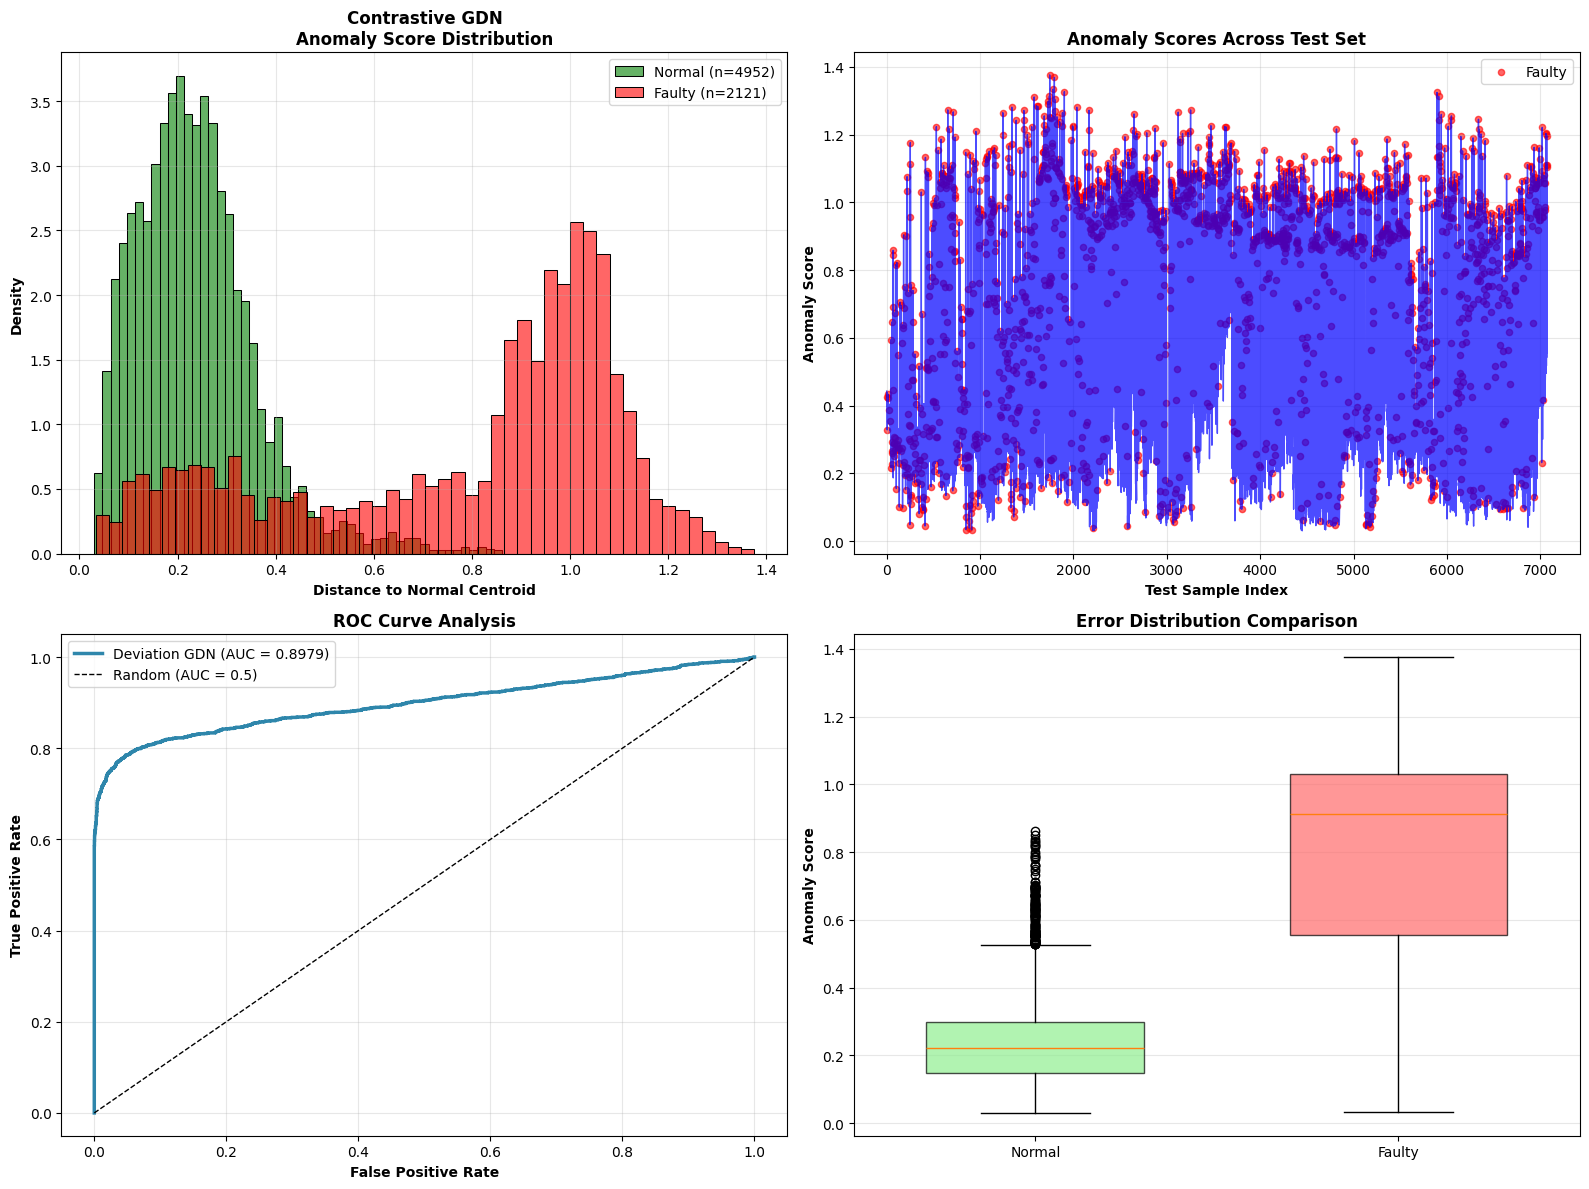


FINAL METRICS
AUC Score: 0.8979
Separation Ratio: 3.33x
Normal Mean Error: 0.236736
Faulty Mean Error: 0.787399



In [40]:
# %%
# VISUALIZE RESULTS

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Per-sensor F1 scores
if len(results['sensor_metrics']) > 0:
    ax = axes[0, 0]
    sensor_metrics = results['sensor_metrics'].sort_values('F1', ascending=True)
    colors = ['red' if f1 < 0.5 else 'orange' if f1 < 0.7 else 'green' 
              for f1 in sensor_metrics['F1']]
    
    ax.barh(range(len(sensor_metrics)), sensor_metrics['F1'], color=colors, alpha=0.7)
    ax.set_yticks(range(len(sensor_metrics)))
    ax.set_yticklabels(sensor_metrics['Sensor'], fontsize=9)
    ax.set_xlabel('F1 Score', fontweight='bold')
    ax.set_title('Per-Sensor Detection Performance', fontweight='bold')
    ax.axvline(0.7, color='black', linestyle='--', label='Good threshold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='x')

# Plot 2: Confusion Matrix Heatmap
ax = axes[0, 1]
cm = results['confusion_matrix']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Anomalous'],
            yticklabels=['Normal', 'Anomalous'])
ax.set_ylabel('True Label', fontweight='bold')
ax.set_xlabel('Predicted Label', fontweight='bold')
ax.set_title('Confusion Matrix\n(All Sensors)', fontweight='bold')

# Plot 3: AUC comparison
ax = axes[1, 0]
if len(results['sensor_metrics']) > 0:
    sensor_metrics = results['sensor_metrics'].sort_values('AUC', ascending=False)
    ax.bar(range(len(sensor_metrics)), sensor_metrics['AUC'], alpha=0.7, color='steelblue')
    ax.set_xticks(range(len(sensor_metrics)))
    ax.set_xticklabels(sensor_metrics['Sensor'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('AUC Score', fontweight='bold')
    ax.set_title('Per-Sensor AUC Ranking', fontweight='bold')
    ax.axhline(0.8, color='green', linestyle='--', label='Excellent (0.8)')
    ax.axhline(0.6, color='orange', linestyle='--', label='Fair (0.6)')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Window-level ROC
ax = axes[1, 1]
from sklearn.metrics import roc_curve

window_scores_max = results['sensor_probs'].max(axis=1)
window_labels = results['sensor_labels'].max(axis=1)

fpr, tpr, _ = roc_curve(window_labels, window_scores_max)
auc = results['window_auc_max']

ax.plot(fpr, tpr, linewidth=2.5, label=f'Multi-Label GDN (AUC = {auc:.3f})', color='#2E86AB')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('Window-Level ROC Curve', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multilabel_gdn_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to: multilabel_gdn_results.png")

import seaborn as sns


# ============ OLD VISUALIZATION ============
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Histogram - Contrastive GDN
sns.histplot(normal_errors, bins=50, color='green', alpha=0.6, 
             label=f'Normal (n={len(normal_errors)})', stat='density', ax=axes[0, 0])
sns.histplot(faulty_errors, bins=50, color='red', alpha=0.6, 
             label=f'Faulty (n={len(faulty_errors)})', stat='density', ax=axes[0, 0])
axes[0, 0].set_xlabel("Distance to Normal Centroid", fontweight='bold')
axes[0, 0].set_ylabel("Density", fontweight='bold')
axes[0, 0].set_title("Contrastive GDN\nAnomaly Score Distribution", fontweight='bold', fontsize=12)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)


# Plot 2: Error over time
axes[0, 1].plot(all_errors, linewidth=1, alpha=0.7, color='blue')
axes[0, 1].scatter(np.where(test_labels.numpy() == 1)[0], 
                  all_errors[test_labels.numpy() == 1], 
                  color='red', s=20, alpha=0.6, label='Faulty')
axes[0, 1].set_xlabel("Test Sample Index", fontweight='bold')
axes[0, 1].set_ylabel("Anomaly Score", fontweight='bold')
axes[0, 1].set_title("Anomaly Scores Across Test Set", fontweight='bold', fontsize=12)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)


# Plot 3: ROC Curves
from sklearn.metrics import roc_auc_score, roc_curve

fpr, tpr, _ = roc_curve(test_labels.numpy(), all_errors)
auc = roc_auc_score(test_labels.numpy(), all_errors)

axes[1, 0].plot(fpr, tpr, linewidth=2.5, label=f'Deviation GDN (AUC = {auc:.4f})', color='#2E86AB')
axes[1, 0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
axes[1, 0].set_xlabel("False Positive Rate", fontweight='bold')
axes[1, 0].set_ylabel("True Positive Rate", fontweight='bold')
axes[1, 0].set_title("ROC Curve Analysis", fontweight='bold', fontsize=12)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Box plot comparison
data_for_boxplot = [
    normal_errors, 
    faulty_errors, 
]
bp = axes[1, 1].boxplot(data_for_boxplot,
                        labels=['Normal', 'Faulty'],
                        patch_artist=True,
                        widths=0.6)

colors = ['#90EE90', '#FF6B6B']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1, 1].set_ylabel("Anomaly Score", fontweight='bold')
axes[1, 1].set_title("Error Distribution Comparison", fontweight='bold', fontsize=12)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print(f"FINAL METRICS")
print(f"{'='*80}")
print(f"AUC Score: {auc:.4f}")
print(f"Separation Ratio: {separation:.2f}x")
print(f"Normal Mean Error: {normal_errors.mean():.6f}")
print(f"Faulty Mean Error: {faulty_errors.mean():.6f}")
print(f"{'='*80}\n")
